In [14]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
from netCDF4 import Dataset
from regrid import regrid
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import tqdm
import itertools
import xarray as xr

https://uitno.app.box.com/s/6ol1xczmmgrv2eupdc7msepuvrk76931?page=2

In [15]:
d1 = Dataset('../SIT/uit_sit_biweekly_v2north_polarstereo_80km_20220723_v3.0.nc')
d2 = Dataset('../SIT/uit_sit_biweekly_v2north_polarstereo_80km_20220807_v3.0.nc')

jl_lon = np.array(d2['longitude'])
jl_lat = np.array(d2['latitude'])
jl_sit = np.array(d2['sea_ice_thickness'])
jl_sno = np.array(d2['snow_depth'])
d2['time_interval']

/tmp/ipykernel_12078/1011151813.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  jl_lon = np.array(d2['longitude'])
/tmp/ipykernel_12078/1011151813.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  jl_lat = np.array(d2['latitude'])
/tmp/ipykernel_12078/1011151813.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration g

<class 'netCDF4.Variable'>
float64 time_interval(time)
    units: days
    comment: number of days over which samples are gridded, centered on "time"
unlimited dimensions: 
current shape = (1,)
filling on, default _FillValue of 9.969209968386869e+36 used

In [16]:
grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
psn_lon = np.fliplr(np.rot90(np.rot90(lon)))
psn_lat = np.fliplr(np.rot90(np.rot90(lat)))

sit = regrid(jl_sit,jl_lon,jl_lat,psn_lon,psn_lat)
sno = regrid(jl_sno,jl_lon,jl_lat,psn_lon,psn_lat)

/tmp/ipykernel_12078/1050922133.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
/home/robbie/custom_modules/regrid.py:19: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  xout, yout = proj.transform(crs_wgs, args, np.array(lon_out),np.array(lat_out))
/home/robbie/custom_modules/regrid.py:21: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  xin, yin = proj.transform(crs_wgs, args, np.array(lon_in),np.array(lat_in))


In [17]:
sit[psn_lat>87.5]=np.nanmean(sit[(psn_lat>87)&(psn_lat<88)])

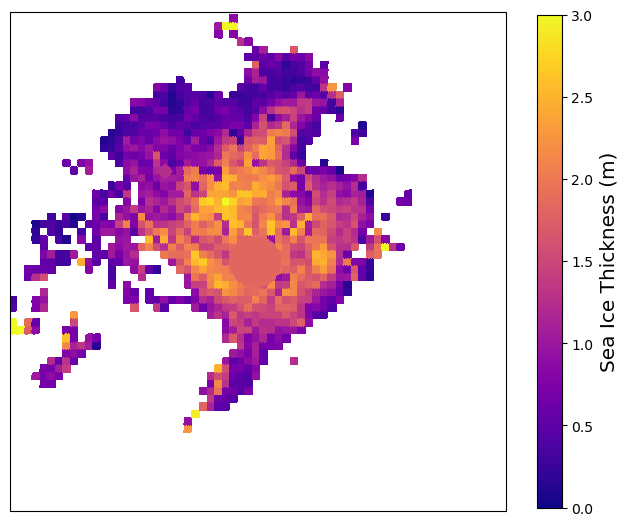

In [36]:
sit2=sit.copy()
y=195
x=423
delta=10
sit2[x:x+delta,y:y+delta]=np.nanmean(sit2[x+10:x+delta+10,y+10:y+delta+10])
sit=sit2
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
# ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.1)
m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  sit2,
                  vmin = 0,
                  vmax = 3,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Sea Ice Thickness (m)',fontsize='x-large')
# plt.savefig('../figs/sit.png',dpi=500,bbox_inches='tight')

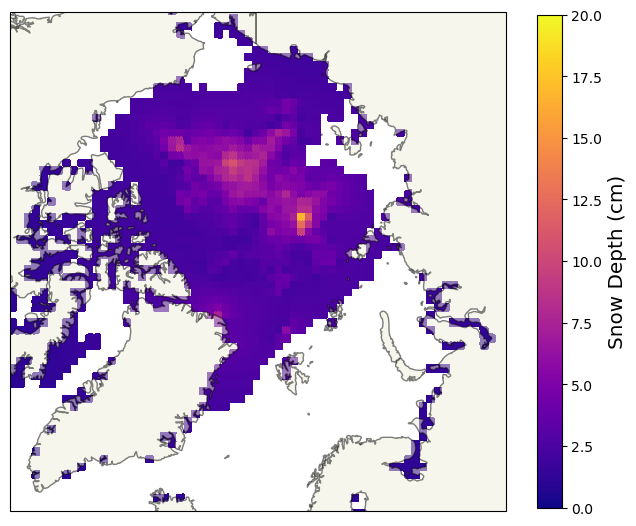

In [37]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  100*sno,
                  vmin = 0,
                  vmax = 20,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Snow Depth (cm)',fontsize='x-large')
# plt.savefig('../figs/snow_depth.png',dpi=500,bbox_inches='tight')

In [38]:
dsno = xr.DataArray(name='snow_depth',
    data=sno,
    coords={'latitude':(['x','y'],psn_lat),
            'longitude':(['x','y'],psn_lon),
           },
    dims=['x','y'],
)

dsit = xr.DataArray(name='sea_ice_thickness',
    data=sit,
    coords={'latitude':(['x','y'],psn_lat),
            'longitude':(['x','y'],psn_lon),
           },
    dims=['x','y'],
)

ds = xr.merge([dsno,dsit])
ds.to_netcdf('inputs/snow_and_sit.nc')

In [40]:
snow_dist_df = pd.read_csv('inputs/sub_km_lookup.csv',index_col='mean_depth')
# snow_dist_df.drop(columns=['Unnamed: 0'],inplace=True)

In [41]:
cols=np.array(snow_dist_df.columns)

In [42]:
snow_dists = np.empty(shape=(sno.shape[0],sno.shape[1],snow_dist_df.shape[1]))

for i,j in itertools.product(range(sno.shape[0]),range(sno.shape[1])):

    mean_depth = sno[i,j].round(2)

    if mean_depth ==0:

        snow_dists[i,j,:]=[0]*snow_dists.shape[2]

    if ~np.isnan(mean_depth):
        
        dist = snow_dist_df.loc[mean_depth]
        
        snow_dists[i,j,:]=dist

# pickle.dump((snow_dists,cols), open('snow_dists_array.p','wb'))

In [43]:
snow_dists_d = xr.DataArray(name='snow_dists',
    data=snow_dists,
    coords={
            'latitude':(['x','y'],psn_lat),
            'longitude':(['x','y'],psn_lon),
            'snow_depths':(['d'],cols),
           },
    dims=['x','y','d'],
)

snow_dists_d.to_netcdf('inputs/snow_dists_array.nc')

In [44]:
hpdf = [0.0646, 0.1415, 0.173, 0.1272, 0.1114, 0.0824, 0.0665, \
         0.0541, 0.0429, 0.0347, 0.0287, 0.024,0.0194, 0.016, 0.0136]
hpdf=np.asarray(hpdf,dtype=np.float32)
np.sum(hpdf)

def get_itd_15(sit):
    ## ITD 15 classes ##
    # # ITD pdf    
#     xdim,ydim=sit.shape
#     print(xdim,ydim)
    ## next is parameterised form obsvs so leave it

    h_cutoff=3.   # maximum 3 times mean ice thickness       
    ## original, gives a mean at 0.96 original
#     h_array = np.arange(h_cutoff/15.0/2.,h_cutoff,h_cutoff/(15.0))
    ## new - gentle push up to 1.002
#     h_array = np.arange(h_cutoff/15.0/1.5,h_cutoff,h_cutoff/(15.0))
    ## even newer - 1.0000006
    h_array = np.linspace(1./14.878/2.,1.00,15)
    h_array *= h_cutoff
#     h_array = np.linspace(3.0/15/2,3.0*29/30,15)
    return [sit]*h_array[None,None,:],hpdf

    # return 


get_itd_15(0.3)

(array([[[0.030246  , 0.09237129, 0.15449657, 0.21662186, 0.27874714,
          0.34087243, 0.40299771, 0.465123  , 0.52724829, 0.58937357,
          0.65149886, 0.71362414, 0.77574943, 0.83787471, 0.9       ]]]),
 array([0.0646, 0.1415, 0.173 , 0.1272, 0.1114, 0.0824, 0.0665, 0.0541,
        0.0429, 0.0347, 0.0287, 0.024 , 0.0194, 0.016 , 0.0136],
       dtype=float32))

In [45]:
sit_dists = np.empty(shape=(sit.shape[0],sit.shape[1],15))

valid_ijs = []

for i,j in itertools.product(range(sit.shape[0]),range(sit.shape[1])):

    mean_sit = sit[i,j]

    if ~np.isnan(mean_sit):
        
        sit_dists[i,j,:]=np.linspace(0,3*mean_sit,15)
        
        valid_ijs.append((i,j))
        
    else:
        
        sit_dists[i,j,:]=[np.nan]*15

In [46]:
sit_dists_d = xr.DataArray(name='sit_dists',
    data=sit_dists,
    coords={
            'latitude':(['x','y'],psn_lat),
            'longitude':(['x','y'],psn_lon),
            'thicknesses':(['d'],np.array(hpdf)),
           },
    dims=['x','y','d'],
)

sit_dists_d.to_netcdf('inputs/sit_dists_array.nc')

In [47]:
i = [x[0] for x in valid_ijs]
j = [x[1] for x in valid_ijs]
df = pd.DataFrame({'i':i,'j':j})
df.to_csv('inputs/valid_ijs.csv')

In [48]:
ijs = pd.read_csv('inputs/valid_ijs.csv')
ijs

,Unnamed: 0,i,j
0,0,152,108
1,1,152,109
2,2,152,117
3,3,152,118
4,4,153,107
...,...,...,...
47564,47564,589,257
47565,47565,589,258
47566,47566,589,259
47567,47567,590,231


In [49]:
valid_ijs = [(x,y) for x,y in zip(ijs['i'],ijs['j'])]